# Physics-Informed Neural Networks for Activity Coefficient Prediction

This notebook presents the development of a physics-informed neural network (PINN) to predict activity coefficients using processed experimental data. By embedding thermodynamic constraints directly into the loss function, we incorporate domain knowledge into the model, ensuring thermodynamic consistency while leveraging a data-driven approach.

## Dependencies

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from torchmetrics.regression import R2Score

## PINN modeling

### Designing the Neural Network Components

Fix the random seed to be used

In [2]:
torch.manual_seed(42)

Define the architecture of the neural network

In [3]:
class NeuralNetArchitecture(nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.layer_1 = nn.Linear(in_dim, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_4 = nn.Linear(16, out_dim)

    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = F.relu(self.layer_3(x))
        x = self.layer_4(x)

        return x

Implement a custom loss function that enforces thermodynamic consistency by embedding the Gibbs-Duhem equation into the standard MSE loss

In [4]:
def gibbs_duhem_loss(
    y_pred: torch.Tensor,
    y_true: torch.Tensor,
    X: torch.Tensor,
    model: torch.nn.Module,
    lambda_gd: float = 1.0,
    lambda_l1: float = 0.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    # MSE loss
    mse_loss = F.mse_loss(y_pred, y_true, reduction="mean")

    # Calculate ln(gamma)
    ln_gamma1 = y_pred[:, 0]
    ln_gamma2 = y_pred[:, 1]

    # Compute partial derivatives
    dgamma1_dx1 = torch.autograd.grad(
        ln_gamma1,
        X,
        grad_outputs=torch.ones_like(ln_gamma1),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    dgamma2_dx1 = torch.autograd.grad(
        ln_gamma2,
        X,
        grad_outputs=torch.ones_like(ln_gamma2),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    # Compute Gibbs-Duhem term
    x1 = X[:, 2]
    x2 = X[:, 5]
    gibbs_duhem_term = x1 * dgamma1_dx1 + x2 * dgamma2_dx1

    # Physics-based loss
    gd_loss = torch.mean(gibbs_duhem_term**2) * lambda_gd

    # L1 regularization term
    l1_loss = (sum(p.abs().sum() for p in model.parameters())) * lambda_l1

    # Total loss
    loss = mse_loss + gd_loss + l1_loss

    return loss, mse_loss, gd_loss, gibbs_duhem_term

### Reading the data

Defining the data path conveniently:

In [5]:
DATA_PATH = Path("../data")

Reading the data into a `pandas.DataFrame`:

In [6]:
data = pd.read_csv(DATA_PATH / "processed" / "toy_problem_training_dataset.csv")

data

,r_1,q_1,x_1,r_2,q_2,x_2,T,gamma_1,gamma_2
0,9.9262,8.296,0.00,5.8486,4.936,1.00,398.839,0.102990,0.000000
1,9.9262,8.296,0.01,5.8486,4.936,0.99,399.213,0.098514,0.000020
2,9.9262,8.296,0.02,5.8486,4.936,0.98,399.590,0.094219,0.000080
3,9.9262,8.296,0.03,5.8486,4.936,0.97,399.971,0.090097,0.000180
4,9.9262,8.296,0.04,5.8486,4.936,0.96,400.355,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
9065,1.4311,1.432,0.96,12.6238,10.456,0.04,338.402,0.013104,2.463479
9066,1.4311,1.432,0.97,12.6238,10.456,0.03,338.273,0.007730,2.612669
9067,1.4311,1.432,0.98,12.6238,10.456,0.02,338.114,0.003613,2.774724
9068,1.4311,1.432,0.99,12.6238,10.456,0.01,337.920,0.000950,2.951347


### PINN training

Defining model constants

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10000

Split the data into train and test

In [8]:
features = data.iloc[:, :-2].values
labels = data.iloc[:, -2:].values

# Separate the test data
X, X_test, y, y_test = train_test_split(
    features, labels, test_size=0.1, random_state=42
)

Defining the Optuna objective function to find the best hyperparameters

In [9]:
def objective(trial):
    # Hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    lambda_gd = trial.suggest_float("lambda_gd", 1e-2, 1e1, log=True)
    lambda_l1 = trial.suggest_float("lambda_l1", 1e-5, 1e-2, log=True)

    # Define the cross-validation folds
    k_folds = 5
    cv = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    val_losses = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Scale the data
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Convert to tensors
        X_train_tensor = torch.tensor(
            X_train_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        X_val_tensor = torch.tensor(
            X_val_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

        # Model and optimizer
        input_size = X_train.shape[1]
        output_size = 2
        model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        # Early stopping setup
        best_val_loss = float("inf")
        patience = EPOCHS / 10
        patience_counter = 0

        for epoch in range(EPOCHS):
            # Training
            model.train()
            outputs = model(X_train_tensor)
            loss = gibbs_duhem_loss(
                outputs, y_train_tensor, X_train_tensor, model, lambda_gd, lambda_l1
            )[0]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Validation
            model.eval()
            val_outputs = model(X_val_tensor)
            val_loss = gibbs_duhem_loss(
                val_outputs, y_val_tensor, X_val_tensor, model, lambda_gd, lambda_l1
            )[0]

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1}. Best val loss: {best_val_loss:.4f}"
                )
                break

        val_losses.append(best_val_loss)

    return np.mean(val_losses)

Get the best hyperparameters

In [10]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best hyperparameters:")
print(study.best_params)

[I 2025-06-01 21:13:32,577] A new study created in memory with name: no-name-22347db4-c81d-4382-977c-07b3e229a2d1
[I 2025-06-01 21:25:35,566] Trial 0 finished with value: 0.3869687855243683 and parameters: {'learning_rate': 1.1220903887969944e-05, 'lambda_gd': 0.9980121184458685, 'lambda_l1': 0.001496160152034006}. Best is trial 0 with value: 0.3869687855243683.
[I 2025-06-01 21:38:00,598] Trial 1 finished with value: 0.03995053991675377 and parameters: {'learning_rate': 5.249852655108606e-05, 'lambda_gd': 0.07556901930595428, 'lambda_l1': 2.182616559302921e-05}. Best is trial 1 with value: 0.03995053991675377.
[I 2025-06-01 21:50:26,881] Trial 2 finished with value: 0.01323937475681305 and parameters: {'learning_rate': 0.0015592686815312914, 'lambda_gd': 1.4750878565129866, 'lambda_l1': 2.157915893054608e-05}. Best is trial 2 with value: 0.01323937475681305.
[I 2025-06-01 22:02:57,085] Trial 3 finished with value: 0.2893249750137329 and parameters: {'learning_rate': 2.6629901459928797

Early stopping at epoch 6094. Best val loss: 0.3221
Early stopping at epoch 3059. Best val loss: 0.2833
Early stopping at epoch 2582. Best val loss: 0.2918


[I 2025-06-01 22:09:29,445] Trial 4 finished with value: 0.29203709959983826 and parameters: {'learning_rate': 0.0003790260902568598, 'lambda_gd': 3.144553259031108, 'lambda_l1': 0.004110509680967173}. Best is trial 2 with value: 0.01323937475681305.


Early stopping at epoch 4454. Best val loss: 0.2979


[I 2025-06-01 22:21:58,223] Trial 5 finished with value: 0.41542778015136717 and parameters: {'learning_rate': 1.8914347819758146e-05, 'lambda_gd': 0.12665931785300724, 'lambda_l1': 0.003986382095437564}. Best is trial 2 with value: 0.01323937475681305.


...

Early stopping at epoch 8971. Best val loss: 0.0092


[I 2025-06-02 00:21:43,188] Trial 15 finished with value: 0.00947982668876648 and parameters: {'learning_rate': 0.0028643760109071143, 'lambda_gd': 0.528366306753672, 'lambda_l1': 1.1238630383597835e-05}. Best is trial 12 with value: 0.006579388584941626.
[I 2025-06-02 00:34:07,266] Trial 16 finished with value: 0.04576225504279137 and parameters: {'learning_rate': 0.001017144986699041, 'lambda_gd': 0.03013791404055999, 'lambda_l1': 0.0002614696360403042}. Best is trial 12 with value: 0.006579388584941626.
[I 2025-06-02 00:46:21,654] Trial 17 finished with value: 0.014670761115849019 and parameters: {'learning_rate': 0.004670700282293584, 'lambda_gd': 0.14084401473375155, 'lambda_l1': 3.849980363561354e-05}. Best is trial 12 with value: 0.006579388584941626.
[I 2025-06-02 00:58:34,014] Trial 18 finished with value: 0.04092214033007622 and parameters: {'learning_rate': 0.009817996360832547, 'lambda_gd': 0.010612134228693266, 'lambda_l1': 0.0002753348875574752}. Best is trial 12 with val

Early stopping at epoch 5589. Best val loss: 0.0085


[I 2025-06-02 02:23:37,459] Trial 25 finished with value: 0.025612013041973115 and parameters: {'learning_rate': 0.004309568275699242, 'lambda_gd': 0.05488951218826374, 'lambda_l1': 0.00012351798466348998}. Best is trial 12 with value: 0.006579388584941626.
[I 2025-06-02 02:35:54,035] Trial 26 finished with value: 0.07749069035053253 and parameters: {'learning_rate': 0.0011307427848089226, 'lambda_gd': 0.018028610874605437, 'lambda_l1': 0.0006164204382853376}. Best is trial 12 with value: 0.006579388584941626.
[I 2025-06-02 02:48:07,516] Trial 27 finished with value: 0.03495613932609558 and parameters: {'learning_rate': 0.0005708759188113886, 'lambda_gd': 0.010326490569746822, 'lambda_l1': 0.00016030817162287348}. Best is trial 12 with value: 0.006579388584941626.
[I 2025-06-02 03:00:25,270] Trial 28 finished with value: 0.015723468363285066 and parameters: {'learning_rate': 0.009872595899688134, 'lambda_gd': 0.04460151257499701, 'lambda_l1': 5.418040793123517e-05}. Best is trial 12 wi

Best hyperparameters:
{'learning_rate': 0.00907906046625479, 'lambda_gd': 0.013140068841061541, 'lambda_l1': 1.1138757970619764e-05}


### PINN evaluation

Define the best hyperparameters

In [11]:
best_lr = study.best_params["learning_rate"]
best_lambda_gd = study.best_params["lambda_gd"]
best_lambda_l1 = study.best_params["lambda_l1"]

Evaluating the model with the best hyperparameters

In [12]:
# Split the dataset into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors and move to device
X_train_tensor = torch.tensor(
    X_train_scaled, dtype=torch.float32, requires_grad=True
).to(DEVICE)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32, requires_grad=True).to(
    DEVICE
)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, requires_grad=True).to(
    DEVICE
)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(DEVICE)

# Model and optimizer
input_size = X_train.shape[1]
output_size = 2
model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

# Early stopping setup
best_val_loss = float("inf")
best_model_state = None
patience = EPOCHS / 10
patience_counter = 0

for epoch in range(EPOCHS):
    # Training
    model.train()
    outputs = model(X_train_tensor)
    loss = gibbs_duhem_loss(
        outputs, y_train_tensor, X_train_tensor, model, best_lambda_gd, best_lambda_l1
    )[0]

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    val_outputs = model(X_val_tensor)
    val_loss = gibbs_duhem_loss(
        val_outputs,
        y_val_tensor,
        X_val_tensor,
        model,
        best_lambda_gd,
        best_lambda_l1,
    )[0]

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1}: Training loss -> {loss.item():.4f}, Validation loss -> {val_loss.item():.4f}"
        )

    if patience_counter >= patience:
        print(
            f"Early stopping at epoch {epoch + 1}. Best validation loss: {best_val_loss:.4f}"
        )
        break

# Load best model parameters
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Final model evaluation
model.eval()
test_outputs = model(X_test_tensor)
test_loss, test_mse, test_gd, test_residuals = gibbs_duhem_loss(
    test_outputs, y_test_tensor, X_test_tensor, model, best_lambda_gd, best_lambda_l1
)

print(f"\nFinal Test Loss: {test_loss.item():.4f}")
print(f" - Test MSE Loss: {test_mse.item():.4f}")
print(f" - Test GD Loss: {test_gd.item():.4f}")

Epoch 20: Training loss -> 0.1780, Validation loss -> 0.1830
Epoch 40: Training loss -> 0.1451, Validation loss -> 0.1484
Epoch 60: Training loss -> 0.1202, Validation loss -> 0.1282
Epoch 80: Training loss -> 0.1030, Validation loss -> 0.1125
Epoch 100: Training loss -> 0.0885, Validation loss -> 0.1039
Epoch 120: Training loss -> 0.0743, Validation loss -> 0.0851
Epoch 140: Training loss -> 0.0735, Validation loss -> 0.1001
Epoch 160: Training loss -> 0.0606, Validation loss -> 0.0679
Epoch 180: Training loss -> 0.0535, Validation loss -> 0.0633
Epoch 200: Training loss -> 0.0499, Validation loss -> 0.0609
Epoch 220: Training loss -> 0.0464, Validation loss -> 0.0545
Epoch 240: Training loss -> 0.0428, Validation loss -> 0.0529
Epoch 260: Training loss -> 0.0392, Validation loss -> 0.0473
Epoch 280: Training loss -> 0.0424, Validation loss -> 0.0558
Epoch 300: Training loss -> 0.0400, Validation loss -> 0.0412
Epoch 320: Training loss -> 0.0323, Validation loss -> 0.0386
Epoch 340: T

Save the final model and scaler

In [13]:
# Save final model and the scaler
MODEL_PATH = Path("./models")
torch.save(model.state_dict(), MODEL_PATH / "trained_pinn.pt")
joblib.dump(scaler, MODEL_PATH / "scaler.pkl")

['models\\scaler.pkl']

Plotting Predicted vs Experimental Values for $\gamma_1$

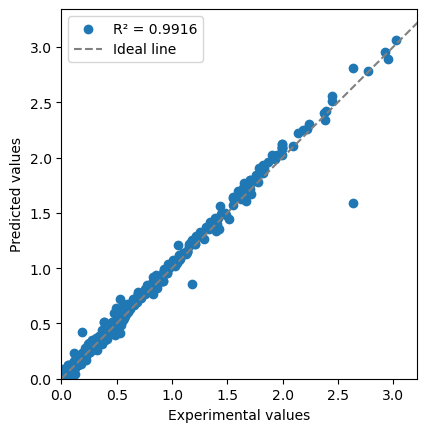

In [14]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 0], y_test_tensor[:, 0]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 0].cpu().numpy()
preds_np = test_outputs[:, 0].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Predicted vs Experimental Values for $\gamma_2$

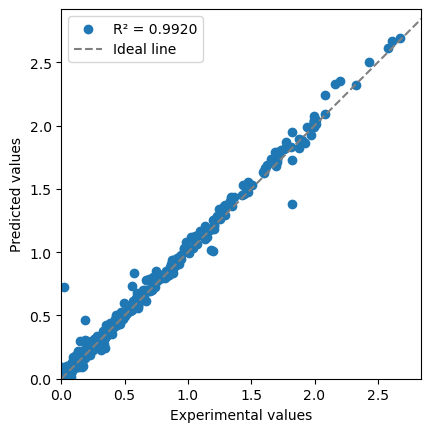

In [15]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 1], y_test_tensor[:, 1]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 1].cpu().numpy()
preds_np = test_outputs[:, 1].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Gibbs-Duhem Residual Values

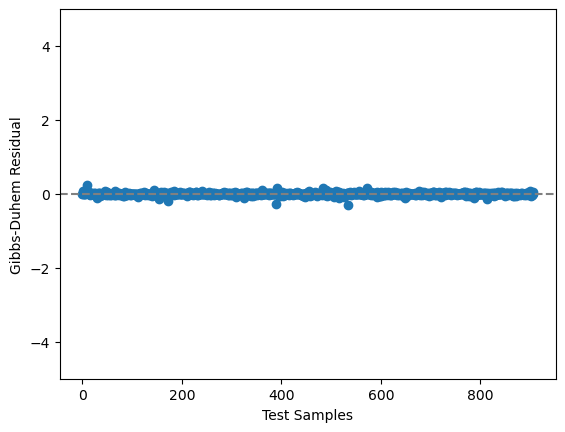

In [16]:
# Convert tensor to NumPy
np_gd_residuals = test_residuals.detach().cpu().numpy()

# Create index for each test sample
test_idxs = np.arange(len(np_gd_residuals))

# Plot residuals against observation index
plt.scatter(test_idxs, np_gd_residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.ylim(-5, 5)
plt.xlabel("Test Samples")
plt.ylabel("Gibbs-Duhem Residual")
plt.show()

Evaluating the distribution of Gibbs-Duhem Residual Values

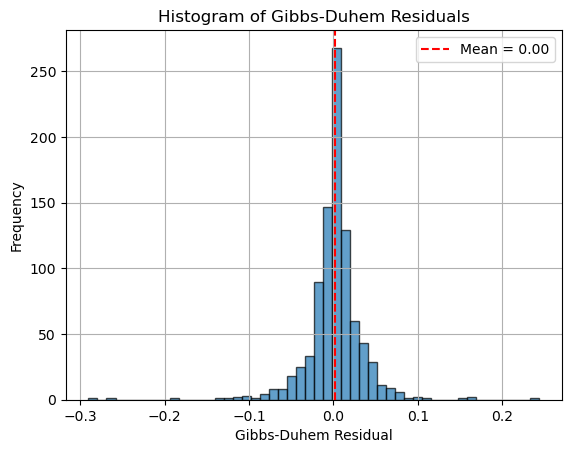

In [17]:
# Convert tensor to NumPy
np_gd_residuals = test_residuals.detach().cpu().numpy()

# Compute mean of residuals
mean_residual = np.mean(np_gd_residuals)

# Plot histogram
plt.hist(np_gd_residuals, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(
    mean_residual, color="red", linestyle="--", label=f"Mean = {mean_residual:.2f}"
)
plt.xlabel("Gibbs-Duhem Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Gibbs-Duhem Residuals")
plt.legend()
plt.grid(True)
plt.show()